In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mymoviedb.csv',lineterminator='\n')
print(df)


     Release_Date                                 Title  \
0      2021-12-15               Spider-Man: No Way Home   
1      2022-03-01                            The Batman   
2      2022-02-25                               No Exit   
3      2021-11-24                               Encanto   
4      2021-12-22                        The King's Man   
...           ...                                   ...   
9822   1973-10-15                              Badlands   
9823   2020-10-01                      Violent Delights   
9824   2016-05-06                          The Offering   
9825   2021-03-31  The United States vs. Billie Holiday   
9826   1984-09-23                               Threads   

                                               Overview  Popularity  \
0     Peter Parker is unmasked and no longer able to...    5083.954   
1     In his second year of fighting crime, Batman u...    3827.658   
2     Stranded at a rest stop in the mountains durin...    2618.087   
3     T

In [3]:
print(df.head())

  Release_Date                    Title  \
0   2021-12-15  Spider-Man: No Way Home   
1   2022-03-01               The Batman   
2   2022-02-25                  No Exit   
3   2021-11-24                  Encanto   
4   2021-12-22           The King's Man   

                                            Overview  Popularity  Vote_Count  \
0  Peter Parker is unmasked and no longer able to...    5083.954        8940   
1  In his second year of fighting crime, Batman u...    3827.658        1151   
2  Stranded at a rest stop in the mountains durin...    2618.087         122   
3  The tale of an extraordinary family, the Madri...    2402.201        5076   
4  As a collection of history's worst tyrants and...    1895.511        1793   

   Vote_Average Original_Language                               Genre  \
0           8.3                en  Action, Adventure, Science Fiction   
1           8.1                en            Crime, Mystery, Thriller   
2           6.3                en        

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB
None


In [5]:
print(df['Genre'].head())

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str


In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9822    False
9823    False
9824    False
9825    False
9826    False
Length: 9827, dtype: bool

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
#Dropping unneccessary columns from the data frame

cols = ['Overview','Original_Language','Poster_Url']
df.drop(cols,axis=1,inplace=True)
print(df.columns)

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')


In [9]:
print(df.head())

  Release_Date                    Title  Popularity  Vote_Count  Vote_Average  \
0   2021-12-15  Spider-Man: No Way Home    5083.954        8940           8.3   
1   2022-03-01               The Batman    3827.658        1151           8.1   
2   2022-02-25                  No Exit    2618.087         122           6.3   
3   2021-11-24                  Encanto    2402.201        5076           7.7   
4   2021-12-22           The King's Man    1895.511        1793           7.0   

                                Genre  
0  Action, Adventure, Science Fiction  
1            Crime, Mystery, Thriller  
2                            Thriller  
3  Animation, Comedy, Family, Fantasy  
4    Action, Adventure, Thriller, War  


In [14]:
#Function for rating label
def categorize_col(df,col,labels):
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]

    df[col] = pd.cut(df[col], edges, labels = labels, duplicates = 'drop')
    return df

labels = ['not_popular','below_average','average','popular']
categorize_col(df,'Vote_Average',labels)
df['Vote_Average'].unique()

#Genre Analysis
#Split comma-separated genres and convert into separate rows.

genres = (
    df['Genre']
    .dropna()
    .str.split(', ')
    .explode()
)

print("\nGenre Summary:")
print(genres.describe())

print("\nTop 10 Genres:")
print(genres.value_counts().head(10))
      


Genre Summary:
count     25793
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

Top 10 Genres:
Genre
Drama        3744
Comedy       3031
Action       2686
Thriller     2488
Adventure    1853
Romance      1476
Horror       1470
Animation    1439
Family       1414
Fantasy      1308
Name: count, dtype: int64


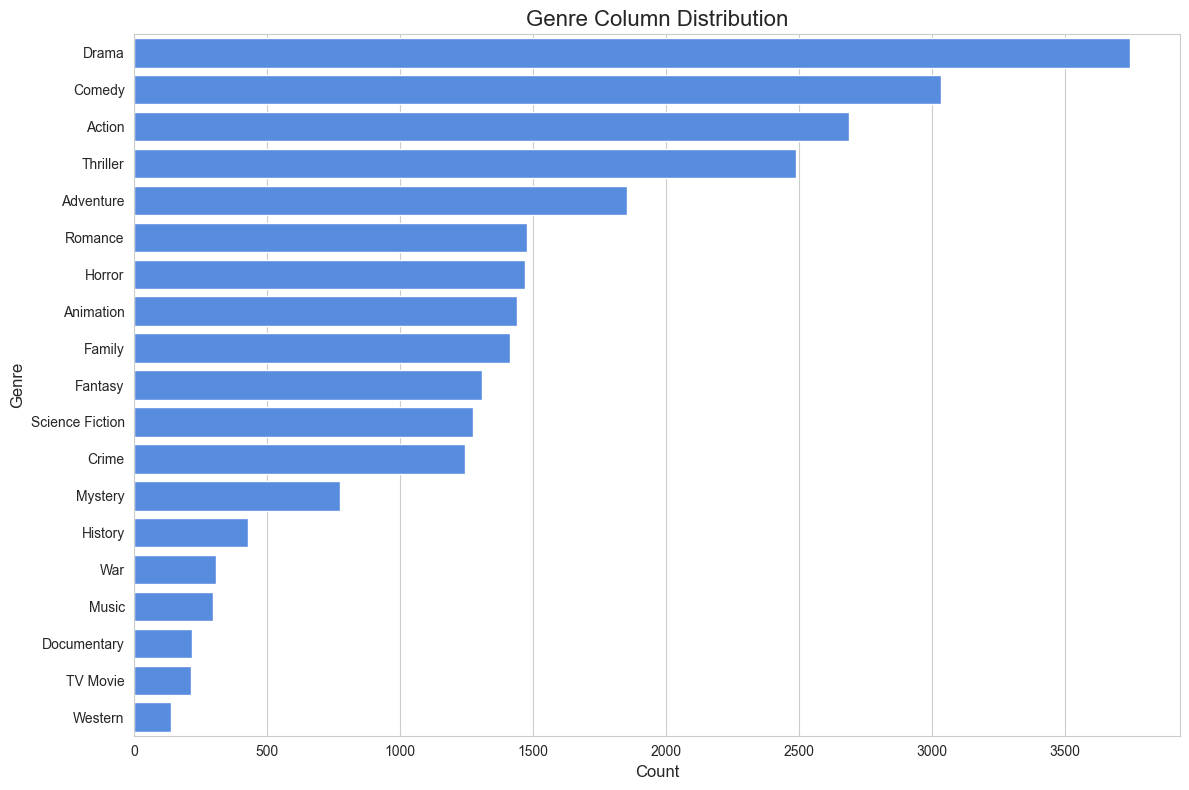

In [15]:
#Data Visualization
#1.What is the most frequent genre of movies released on Netflix?
sns.set_style('whitegrid')
plt.figure(figsize=(12,8))
sns.countplot(
    y = genres,
    order = genres.value_counts().index,color = "#4287f5"
)

plt.title('Genre Column Distribution', fontsize = 16)
plt.xlabel('Count',fontsize = 12)
plt.ylabel('Genre', fontsize = 12)
plt.tight_layout()
plt.show()

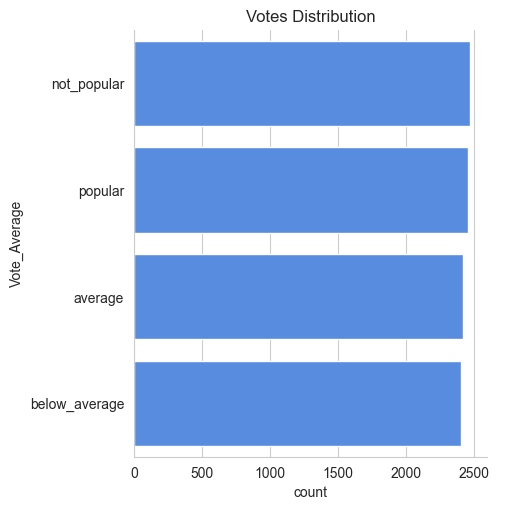

In [17]:
#2. What genres has highest votes?
sns.catplot(y = 'Vote_Average', data =df, kind='count', order = df['Vote_Average'].value_counts().index,color = '#4287f5')
plt.title("Votes Distribution")
plt.show()

In [18]:
#3. What movie got the highest popularity? what's its genre?
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"


In [19]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"


In [ ]:
#Conclusion: Spider-Man: No Way Home has got the highest popularity. From the genre :Action, Adventure, Science Fiction

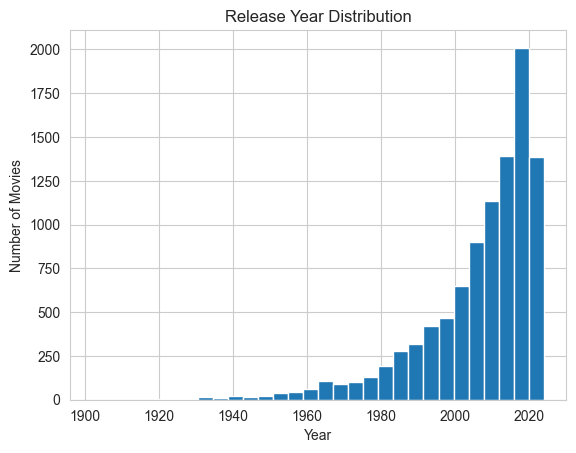

In [24]:
#4. What movie got the lowest popularity? what's its genre?
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Release_Year'] = df['Release_Date'].dt.year

df['Release_Year'].hist(bins=30)
plt.title("Release Year Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

In [ ]:
#Conclusion: 2019 appears to be the year in which the highest number of movies were released.

Year with the most movies: 2021


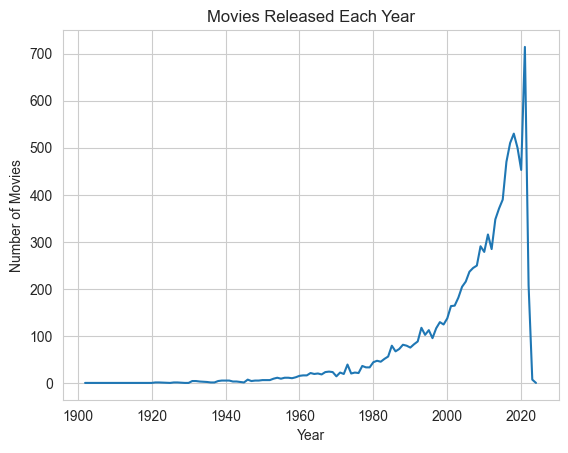

In [25]:
#5. Which year has the most filmmed movies?
# Convert Release_Date to datetime
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

# Extract year
df['Year'] = df['Release_Date'].dt.year

# Find the year with the most movies
print("Year with the most movies:", df['Year'].mode()[0])

# Plot movies released each year
df['Year'].value_counts().sort_index().plot()

plt.title("Movies Released Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

In [ ]:
#Conclusion : Year 2021 has the most filmmed movies.